In [1]:
#Import Relevant Libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

2025-04-20 20:00:27.254728: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Create sequences of past stock prices
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


The mean squared error is 0.04

This is the Expected output[[ 2.14100006e+02  2.17490005e+02  2.12220001e+02  2.13990005e+02
   4.88629000e+07  2.13904004e+02  2.16113998e+02  2.11402002e+02
   2.13386002e+02 -1.13999939e+00 -1.26998901e+00 -1.52999878e+00
  -2.29995728e-01  9.32433187e-01  1.95615240e+00  1.70002006e+00
   1.24777148e+00 -5.29641034e-01 -1.01543797e-01  2.15240005e+02
   2.18759995e+02  2.13750000e+02  2.14220001e+02  5.43854000e+07
   2.15768870e+02  2.12039138e+02  2.20026303e+02  2.12201694e+02
   2.14802042e+02  2.08001962e+02  2.15881545e+02  2.10890459e+02]]

This is the predicted output[[ 2.14100006e+02  2.17490005e+02  2.12220001e+02  2.13990005e+02
   4.88629000e+07  2.13904004e+02  2.16113998e+02  2.11402002e+02
   2.13386002e+02 -1.13999939e+00 -1.26998901e+00 -1.52999878e+00
  -2.29995728e-01  9.32433187e-01  1.95615240e+00  1.70002006e+00
   1.24777148e+00 -5.29641034e-01 -1.01543797e-01  2.15240005e+02
   2.18759995e+02  2.13750000e+02  2.14220001e+02  5

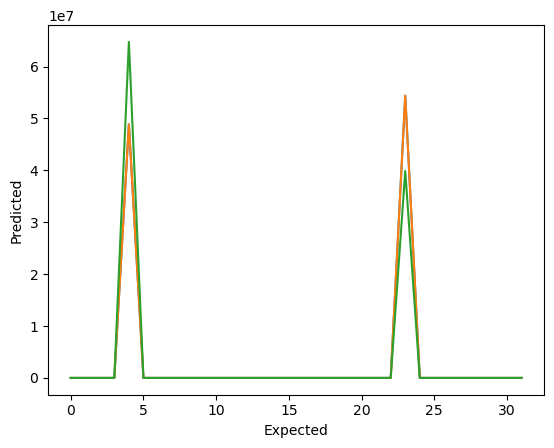

In [3]:
sequence_length = 2

#Download data and Preprocess
stock_data = yf.download("AAPL", start="1980-12-16", end="2025-03-23")
data = pd.DataFrame(stock_data)

# Feature Engineering
data['Close_AVG'] = stock_data['Close'].rolling(window=5).mean().fillna(0)
data['High_AVG'] = stock_data['High'].rolling(window=5).mean().fillna(0)
data['Low_AVG'] = stock_data['Low'].rolling(window=5).mean().fillna(0)
data['Open_AVG'] = stock_data['Open'].rolling(window=5).mean().fillna(0)
data['Momentum_Close'] = stock_data['Close'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_High'] = stock_data['High'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Low'] = stock_data['Low'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Open'] = stock_data['Open'].diff().fillna(0)  # Replace NaN with 0
data['Volatility_Close'] = stock_data['Close'].rolling(window=5).std().fillna(0)
data['Volatility_High'] = stock_data['High'].rolling(window=5).std().fillna(0)
data['Volatility_Low'] = stock_data['Low'].rolling(window=5).std().fillna(0)
data['Volatility_Open'] = stock_data['Open'].rolling(window=5).std().fillna(0)
data['ROC'] = (stock_data['Close'].pct_change() * 100).fillna(0)  # Rate of Change in %
data['Volume_Change'] = stock_data['Volume'].pct_change().fillna(0)
data['Close_Lag'] = stock_data['Close'].shift(1).fillna(0)
data['High_Lag'] = stock_data['High'].shift(1).fillna(0)
data['Low_Lag'] = stock_data['Low'].shift(1).fillna(0)
data['Open_Lag'] = stock_data['Open'].shift(1).fillna(0)
data['Volume_Lag1'] = data['Volume'].shift(1).fillna(0)
data['Close_Upper'] = data['Close_AVG'] + (stock_data['Close'].rolling(window=5).std().fillna(0).reindex(data.index) * 2).squeeze()
data['Close_Lower'] = data['Close_AVG'] - (stock_data['Close'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['High_Upper'] = data['High_AVG'] + (stock_data['High'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['High_Lower'] = data['High_AVG'] - (stock_data['High'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Low_Upper'] = data['Low_AVG'] + (stock_data['Low'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Low_Lower'] = data['Low_AVG'] - (stock_data['Low'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Open_Upper'] = data['Open_AVG'] + (stock_data['Open'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Open_Lower'] = data['Open_AVG'] - (stock_data['Open'].rolling(window=5).std().fillna(0) * 2).squeeze()

data = data.replace([np.inf, -np.inf], np.nan)
data.fillna(0, inplace=True)  # or a meaningful fill value

data_list = data.values.tolist()
data_list = np.array(data_list, dtype = np.float64)

# Replace -inf with -257 and inf with 257
data_list[np.isneginf(data_list)] = -257
data_list[np.isposinf(data_list)] = 257

#Splitting data to test and train
index_marker = int(len(data_list)*0.3)
data_test_unscaled = data_list[:index_marker]
data_train_unscaled = data_list[index_marker - sequence_length:]

next_day = data_train_unscaled[-2:]

#Scaling data
scaler = RobustScaler(quantile_range = (1.0, 99.0))
train_scaled = scaler.fit_transform(data_train_unscaled)
test_scaled = scaler.transform(data_test_unscaled)
next_day = scaler.transform(next_day)

X_test, y_test = create_sequences(test_scaled, sequence_length)
X_train, y_train = create_sequences(train_scaled, sequence_length)

X_train = X_train.reshape(X_train.shape[0],-1)
X_test = X_test.reshape(X_test.shape[0],-1)
next_day = next_day.reshape(1,-1)

prediction_data = X_train[-2].reshape(1,-1)
expected_data = y_train[-2].reshape(1,-1)

#######################################
# reg = LinearRegression()
# reg.fit(X_train, y_train)
# result = reg.predict(prediction_data)
# next_day_result = reg.predict(next_day)
#######################################

####################################################
reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)
result = reg.predict(prediction_data)
next_day_result = reg.predict(next_day)
####################################################

#Calculating my MSE value
y_pred = reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"The mean squared error is {mse:.2f}\n")

predictedX = scaler.inverse_transform(result)
expected = scaler.inverse_transform(expected_data)
next_day_result = scaler.inverse_transform(next_day_result)
difference = expected - predictedX
print(f"This is the Expected output{expected}\n")
print(f"This is the predicted output{predictedX}\n")
print(f"This is the difference between the expected and the predicted output {difference}\n")
print(f"This is the next day data {next_day_result}\n")

#The spike on the graph is the volume of the stock
plt.plot(expected[0]) #Appears as Blue on the graph
plt.plot(predictedX[0]) #Appears as Orange on the graph
plt.plot(next_day_result[0]) #Appears as Green on the graph
plt.xlabel("Expected")
plt.ylabel("Predicted")
plt.show()